## Some additional plots for thesis

In [1]:
#%% Loading packages
import numpy as np

import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import fsspec
from matplotlib import cm
from matplotlib.colors import Normalize 
from scipy.interpolate import interpn
import glob
from functools import partial
import sys
#sys.path.append('/home/u/u301238/master_thesis/')
sys.path.append('/home/u/u301032/orcestra/NN_IWP_retrieval/')
#import src
import src_comparison_halo_pamtra as chp

import matplotlib.colors as colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature


### Plot ideas

all flights plus dropsondes

flights with ITCZ line

### BTs HAMP vs PAMTRA

PAMTRA is blue, HAMP is orange

In [36]:
print('HAMP: min: ',np.min(ds_halo.TBs),' max: ',ds_halo.TBs.max())
print('PAMTRA: min: ',np.min(ds_pamtra.tb),' max: ',ds_pamtra.tb.max())
#ds_pamtra.tb 

HAMP: min:  <xarray.DataArray 'TBs' ()> Size: 4B
array(83.74228, dtype=float32)  max:  <xarray.DataArray 'TBs' ()> Size: 4B
array(319.06778, dtype=float32)
PAMTRA: min:  <xarray.DataArray 'tb' ()> Size: 4B
dask.array<_nanmin_skip-aggregate, shape=(), dtype=float32, chunksize=(), chunktype=numpy.ndarray>  max:  <xarray.DataArray 'tb' ()> Size: 4B
dask.array<_nanmax_skip-aggregate, shape=(), dtype=float32, chunksize=(), chunktype=numpy.ndarray>


### BTs HAMP vs PAMTRA

PAMTRA is blue, HAMP is orange

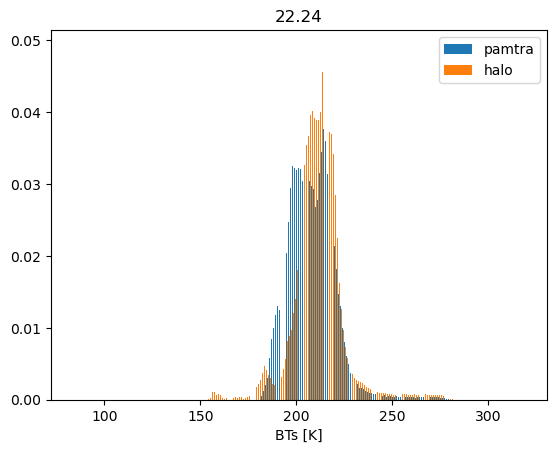

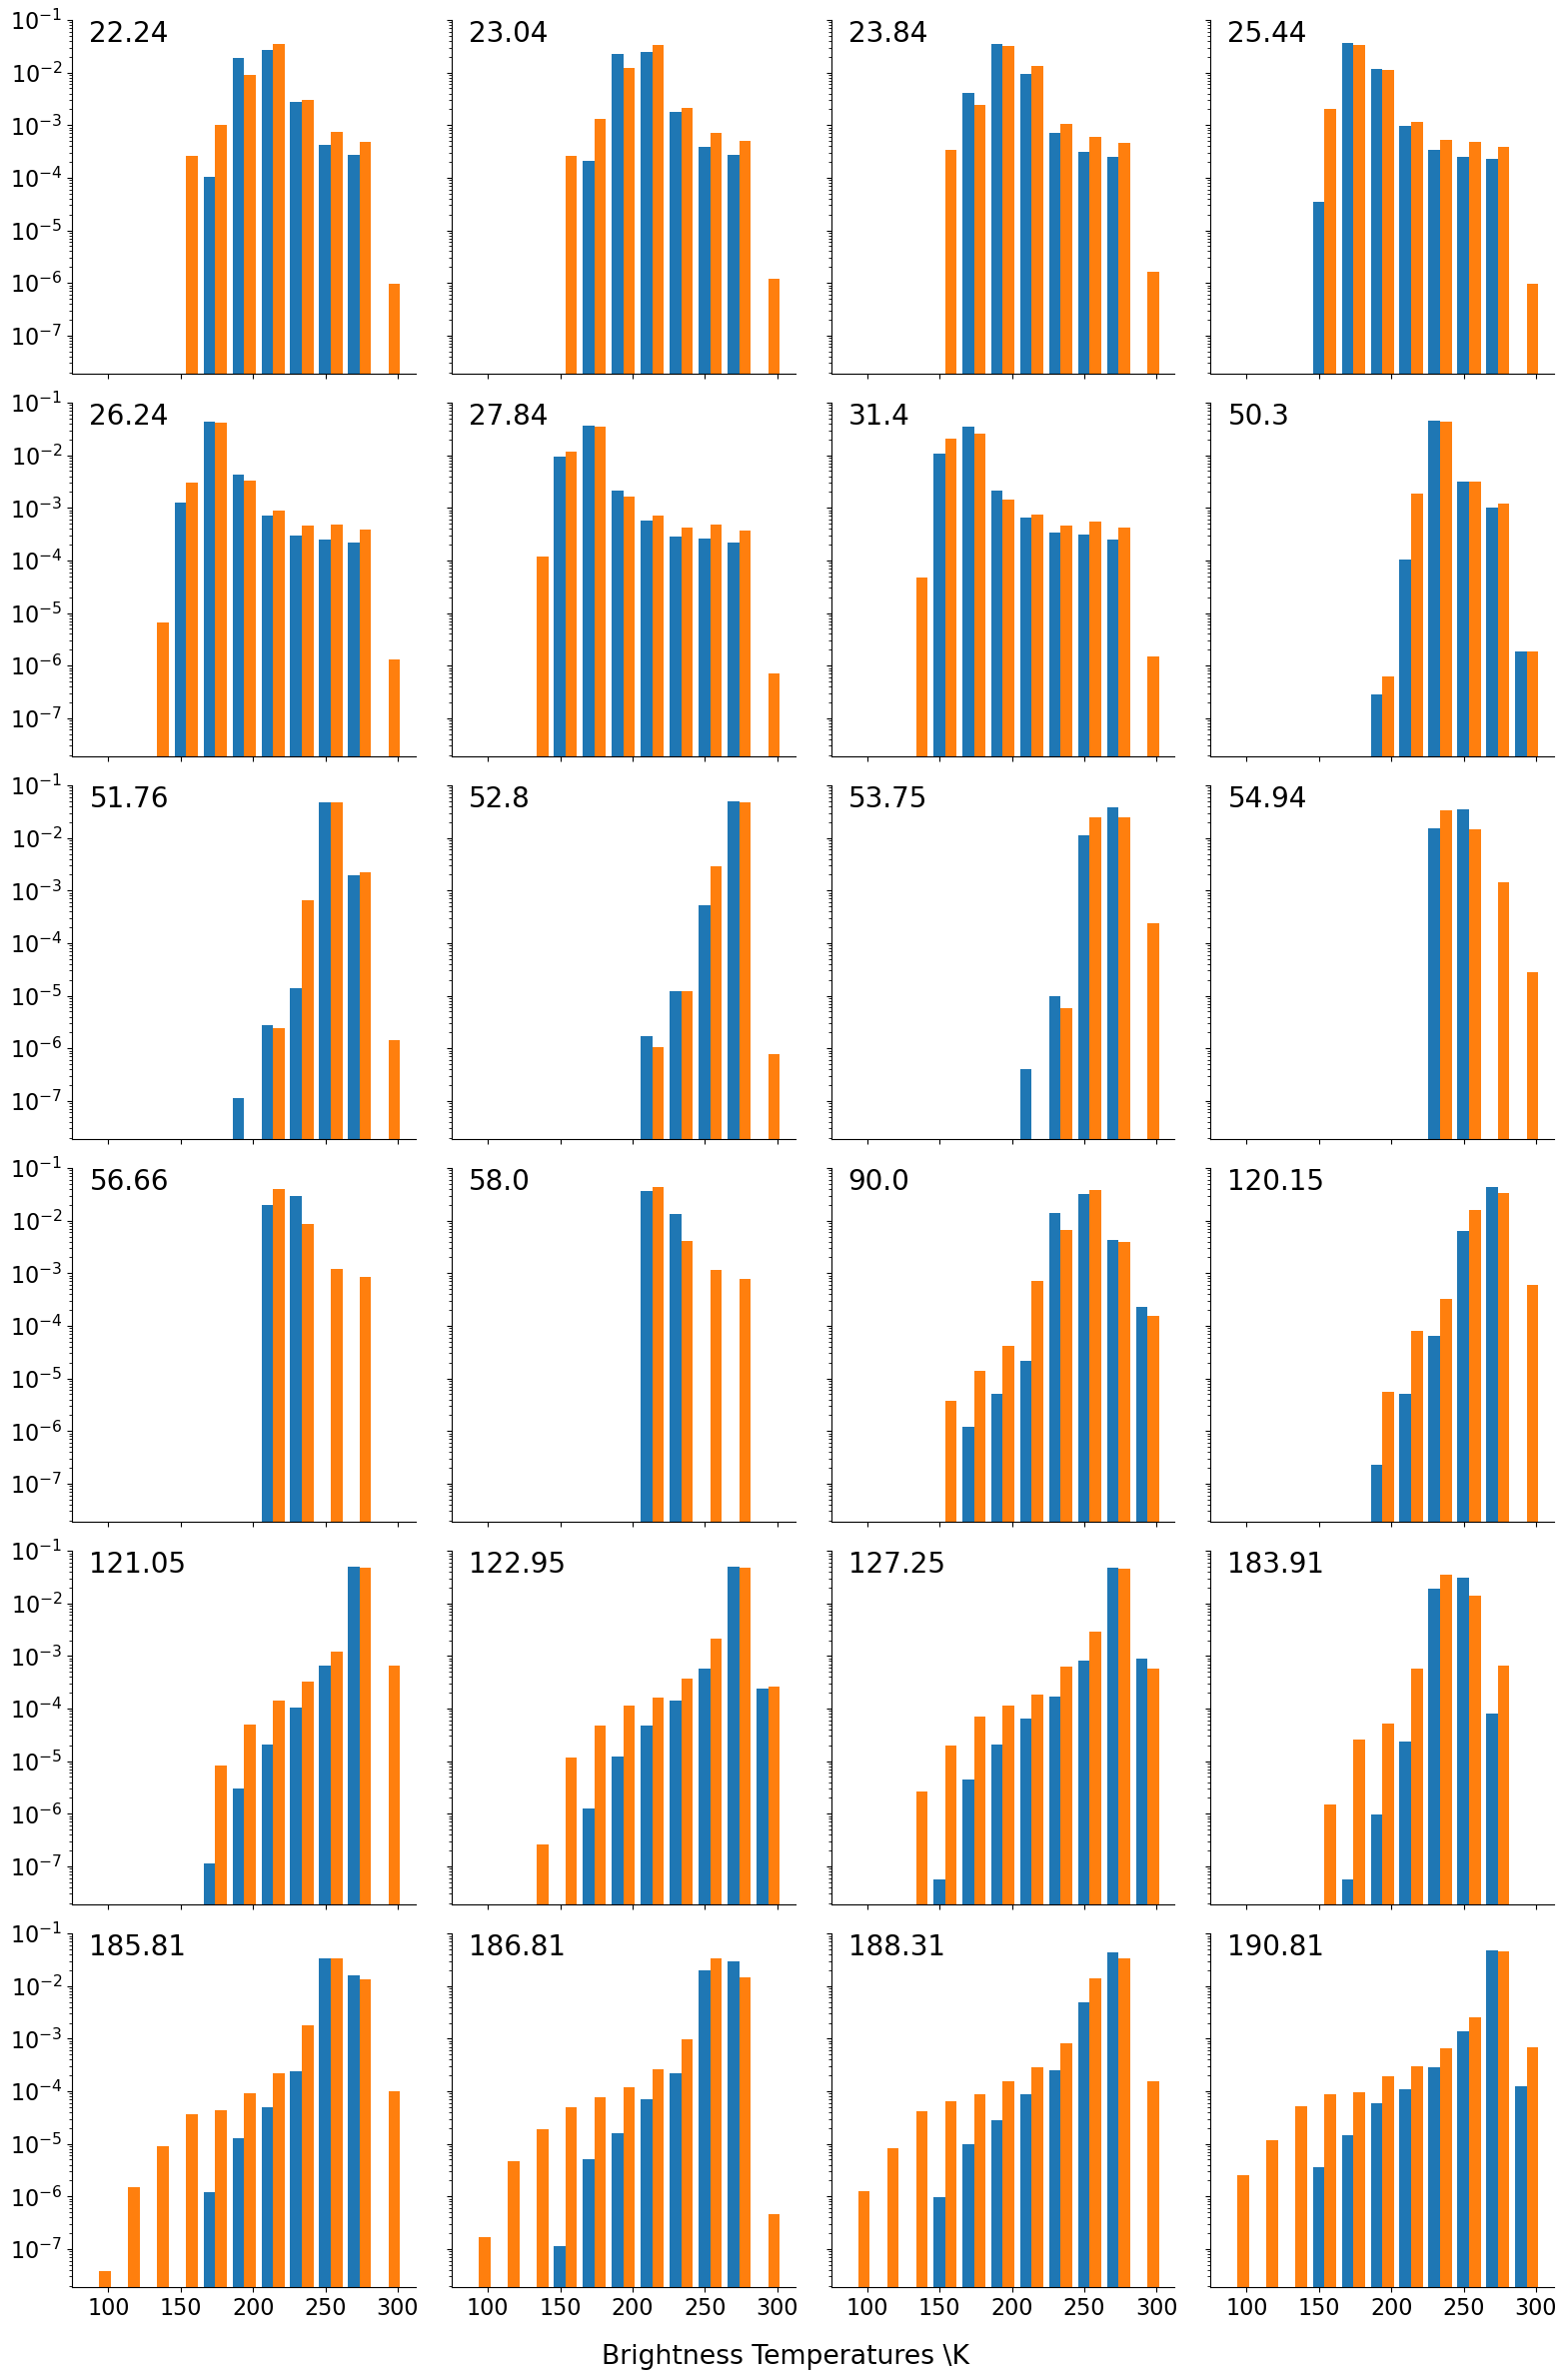

In [2]:
#%% Reading pamtra simulation
# cut heights
#ds_HAMP=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_HAMP.nc")
#ds_halo_altitude=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_altitude.nc") 
#[altitudes<=10500] 
# add noise
# bias and std
name_pamtra_run = "cells_025x025_2h"#"all_area_1000th_cell" # 
TBs = chp.pamtra_TBs_all_heights_combined(name_pamtra_run)
    
pamtra_files='/work/um0203/u301032/PAMTRA_output/PAMTRA-ICON_0829*_025x025_2h_v1.nc'
ds_halo, ds_pamtra =chp.pamtra_halo_BT_read_in(pamtra_files) # pamtra here does not contain noise
#example plot for one frequency:
#chp.pamtra_halo_BT_plot(ds_halo, ds_pamtra,freq=22.24) #without noise on pamtra


#chp.plotting_multiple('BTs_HAMPvsPAMTRA')  
chp.plotting_multiple_no_noise(None,log=True)  

In [4]:
ds_halo = chp.halo_BT_read_in()
name_pamtra_run = "cells_025x025_2h"#"all_area_1000th_cell" # 
TBs = chp.pamtra_TBs_all_heights_combined(name_pamtra_run)


In [7]:
i=0
freq=np.array(ds_halo.frequency)[i]
bias=np.mean(TBs[:,i])-np.mean(ds_halo.sel(frequency =freq).TBs)

In [17]:
print(str(np.round(bias.values,2))+' K')

-4.47 K


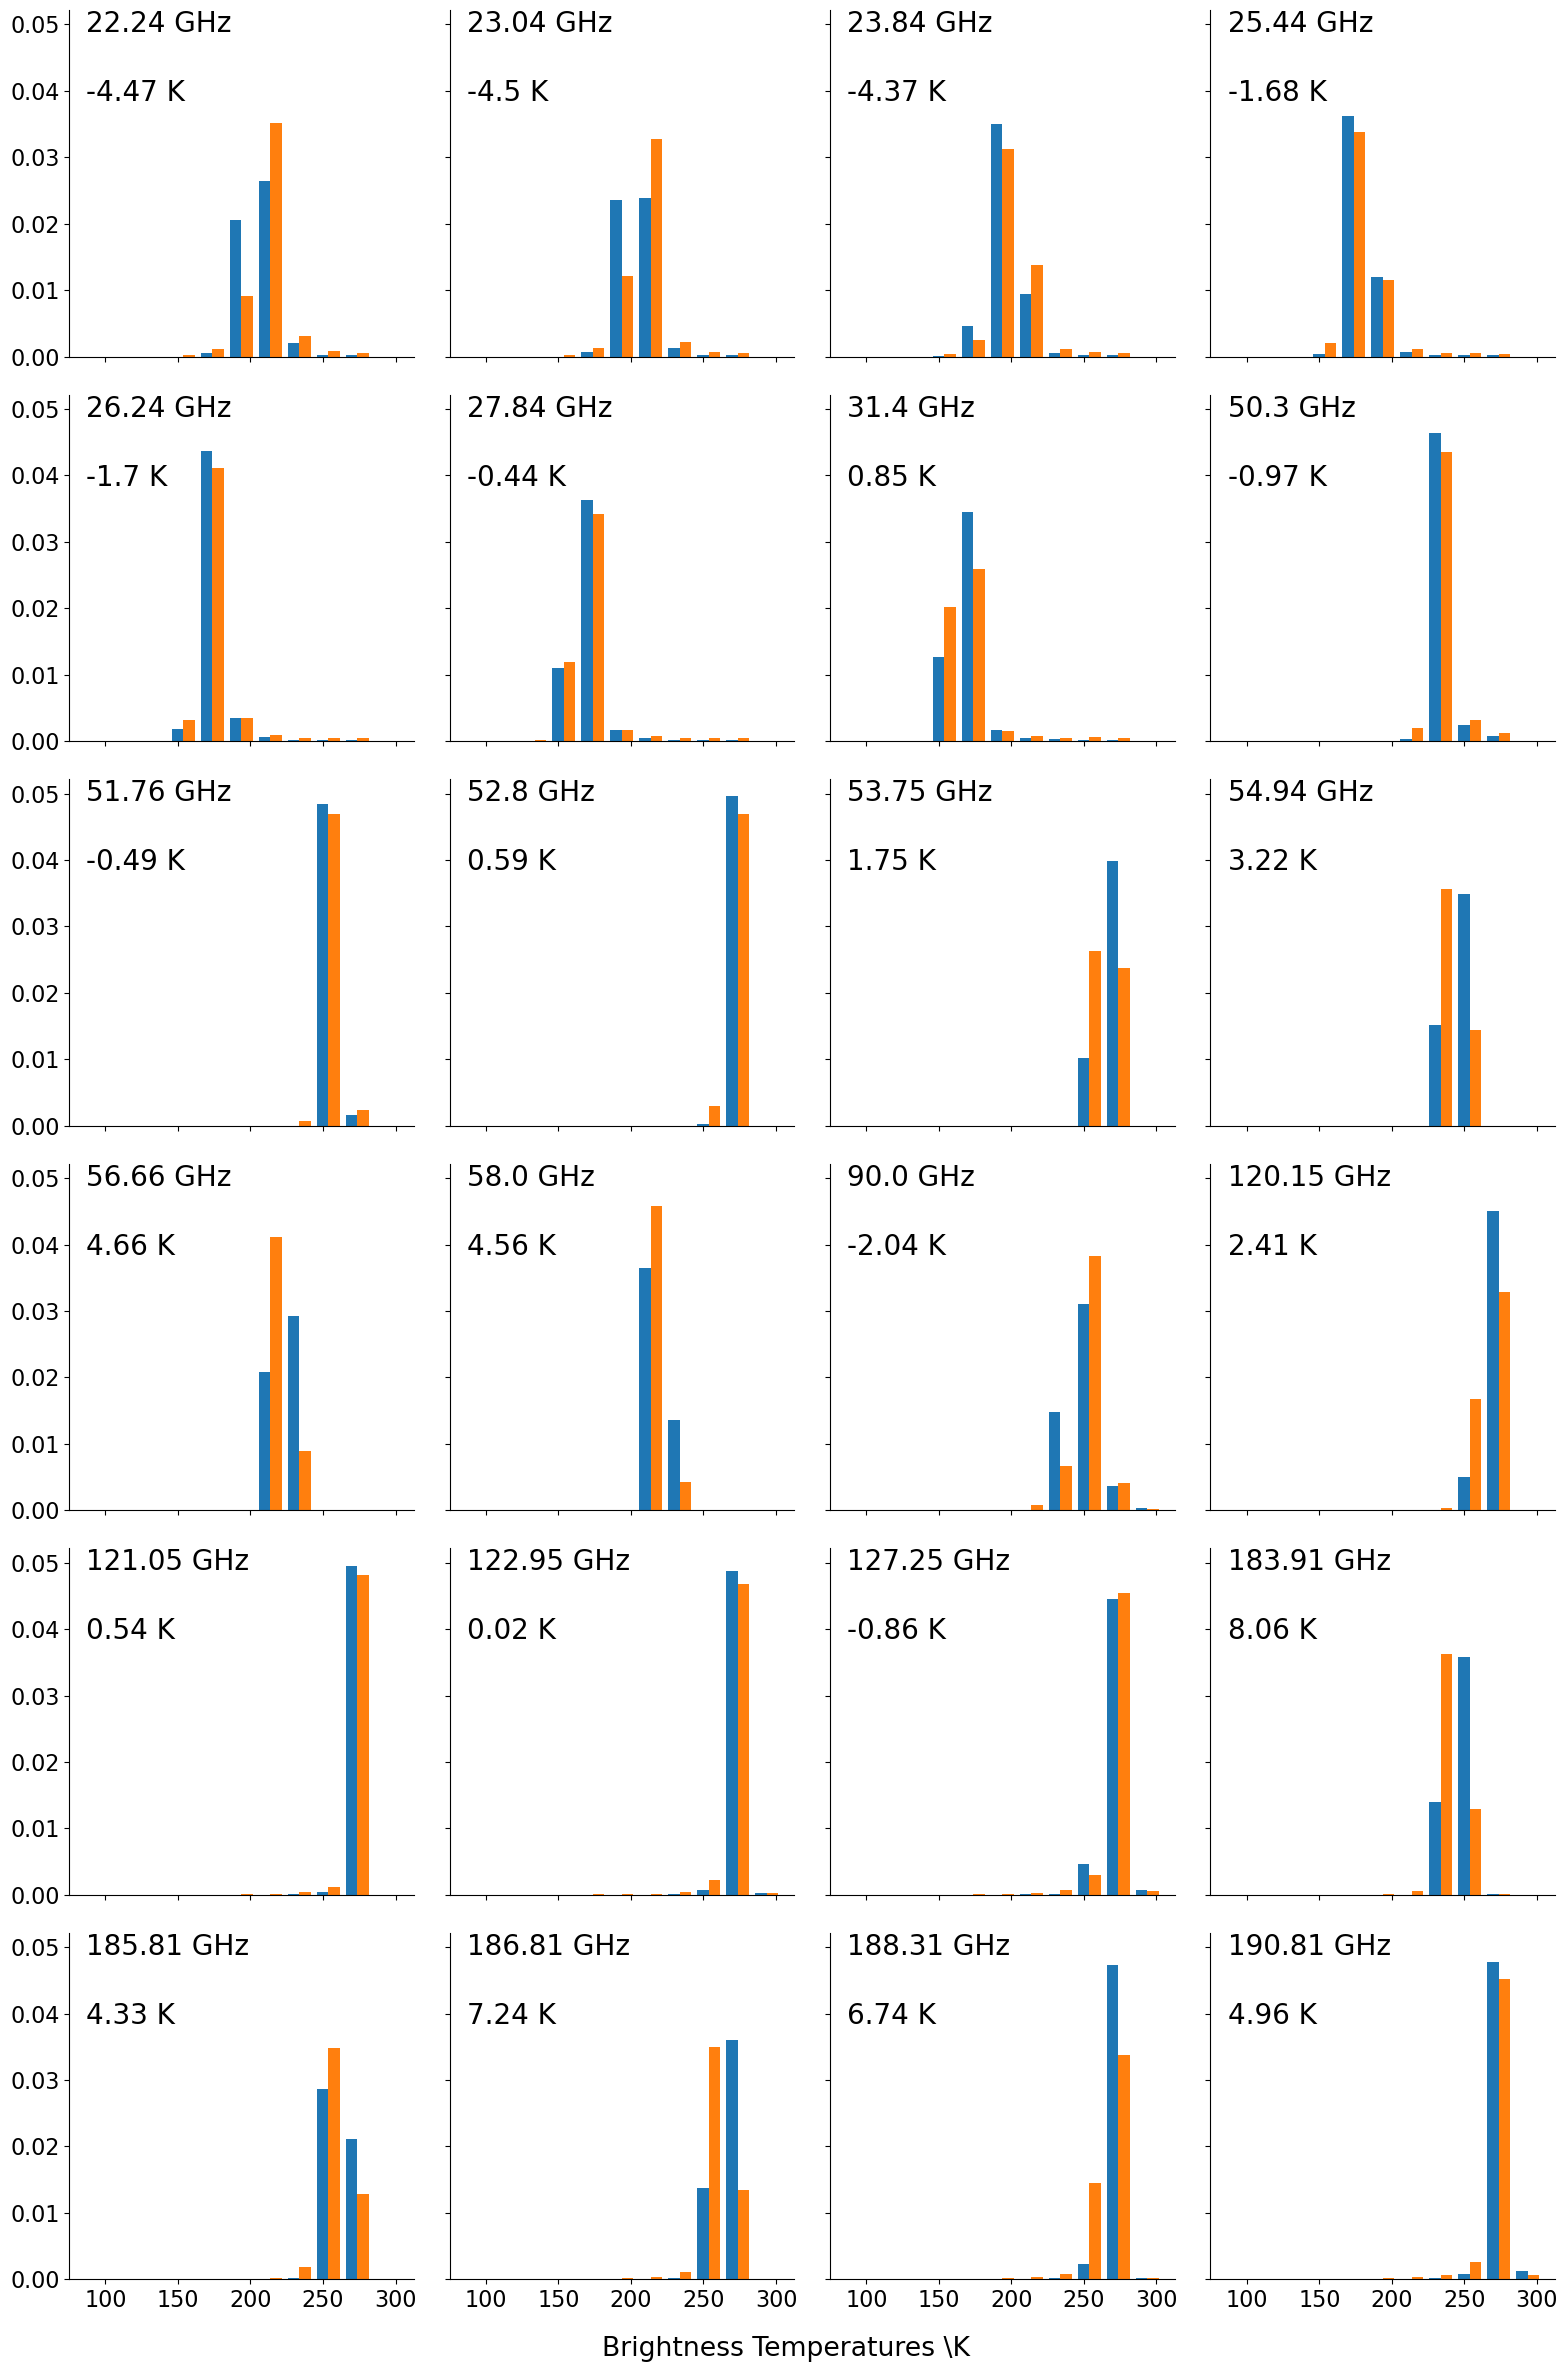

In [2]:
ds_halo=chp.plotting_multiple_with_noise(filename=None,log=False) #None #'v1'


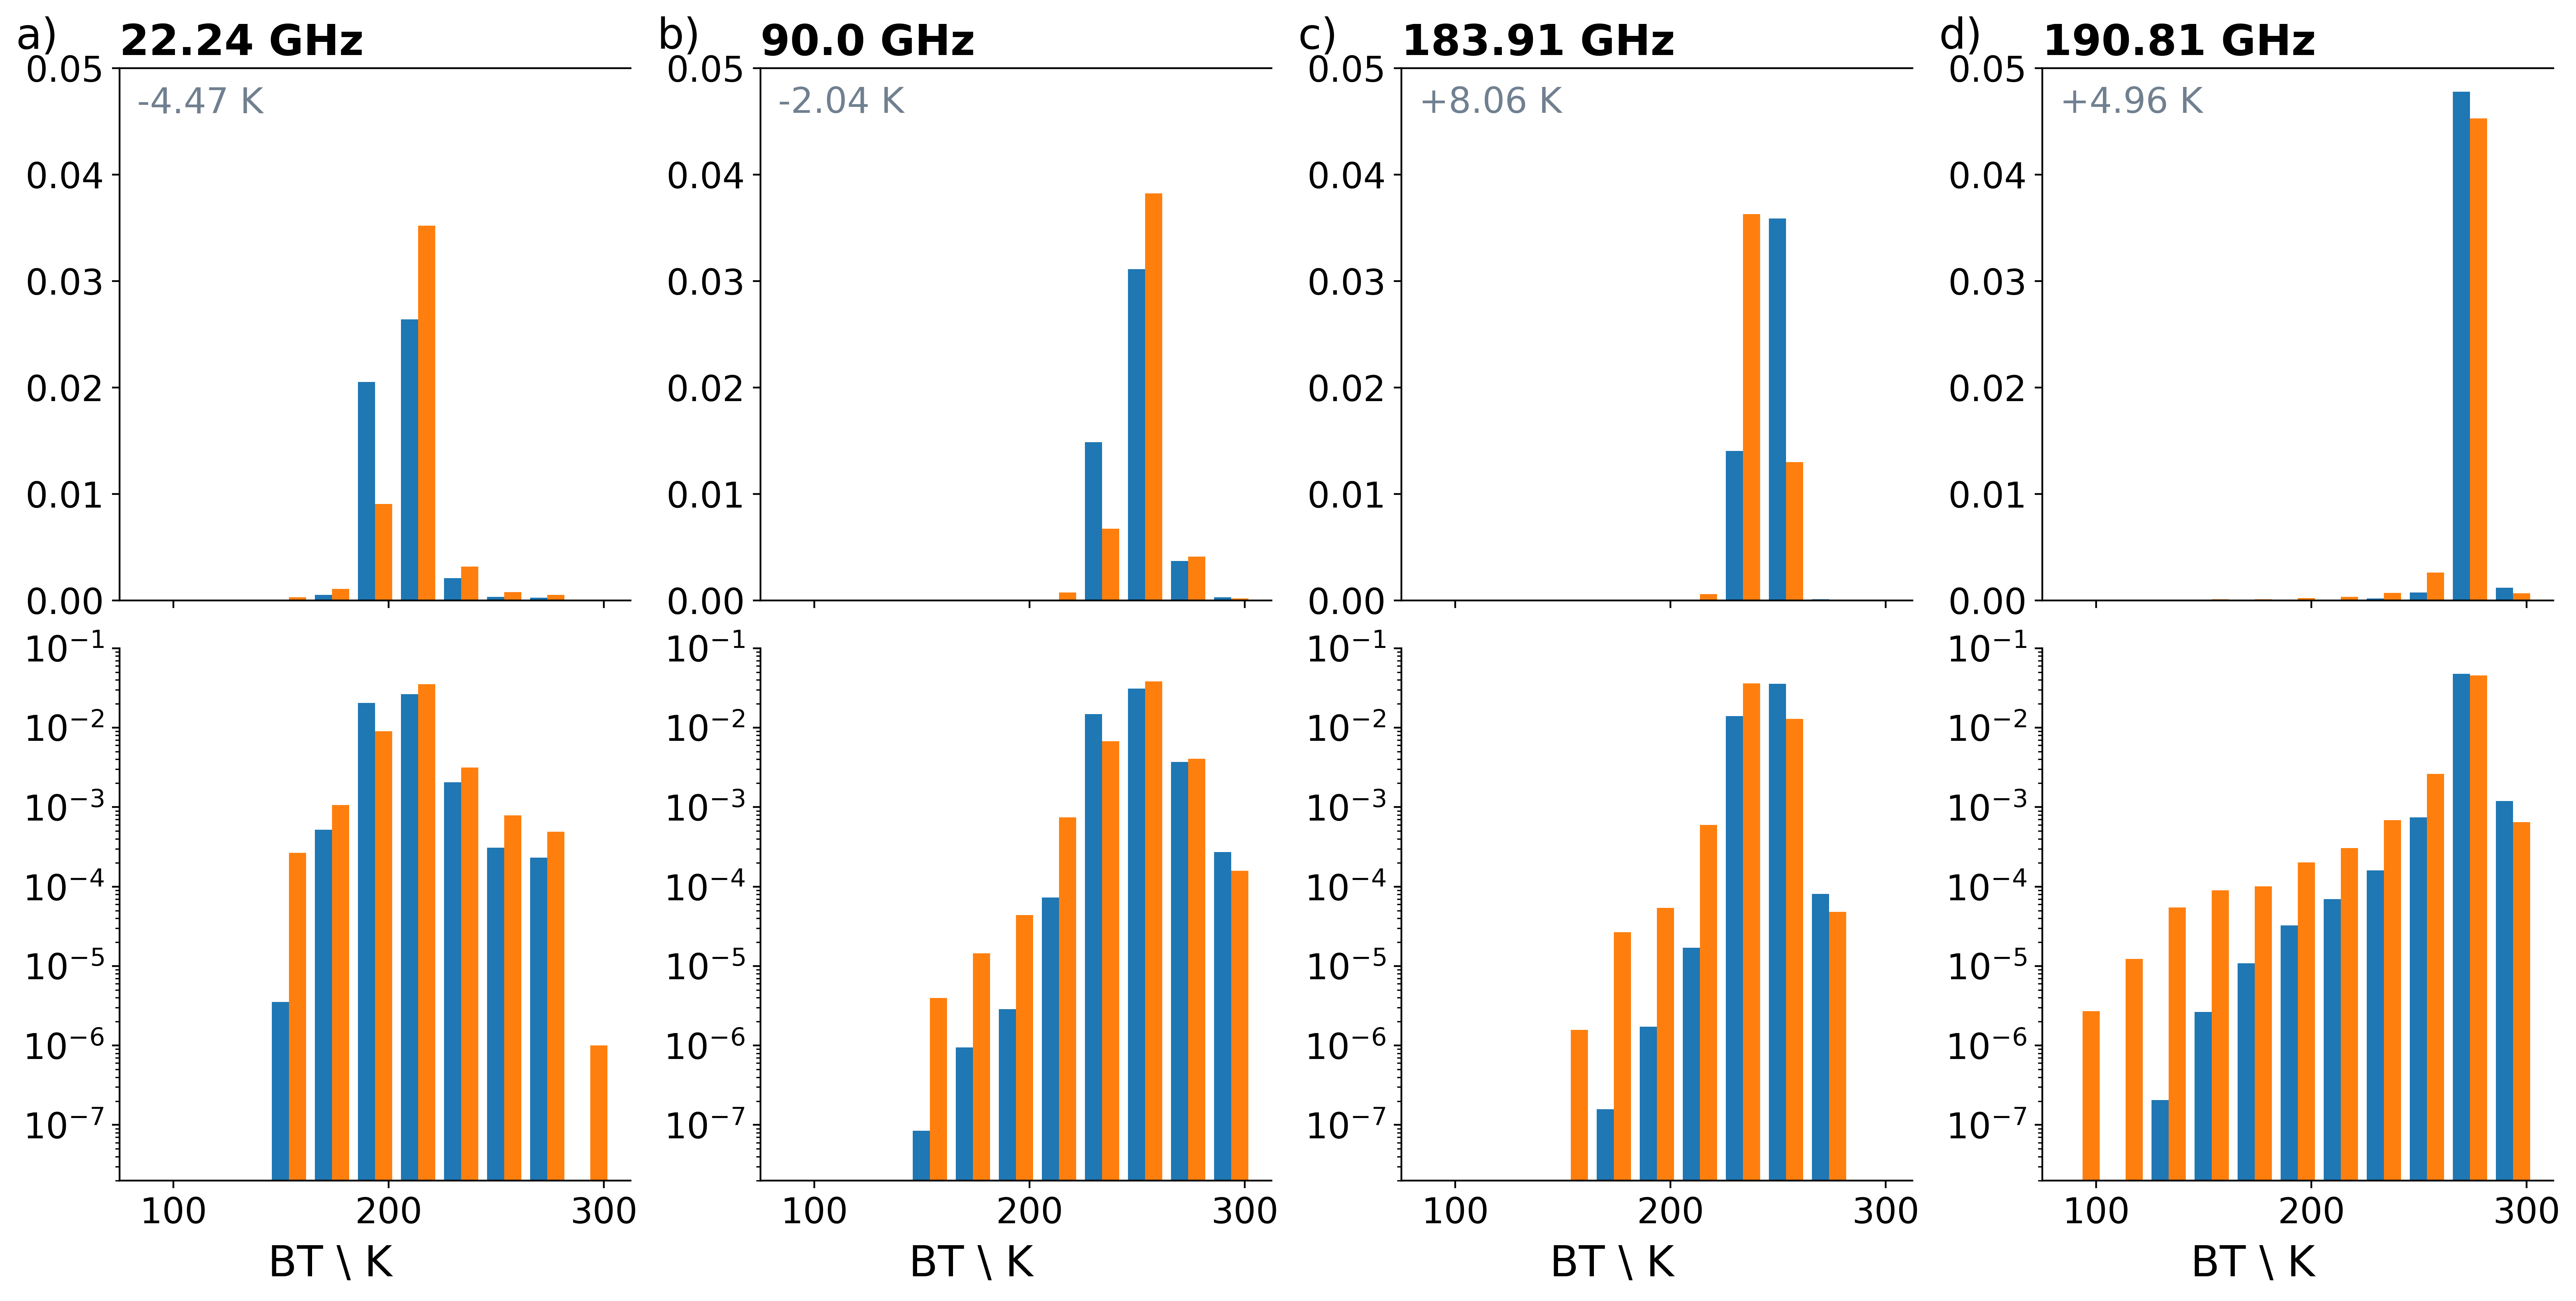

In [4]:

chp.plotting_fav4_noise(filename= 'v1')#

### FLights of HALO with dropsondes



In [3]:
import matplotlib.colors as colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature


#sc = ax.scatter(lon[idx_sea],lat[idx_sea], s=0.1,marker=',', transform=ccrs.PlateCarree())

#ds_hamp=xr.open_dataset('/work/um0203/u301032/master_thesis/retrieved_data/HAMP_with_IWV_IWP_LWP_v1-1.nc')
#ds_iwv_kw=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_iwv_kw.nc")
ds_sondes=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_sondes.nc")
#ds_halo_altitude=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_altitude.nc") 
ds_radar=xr.open_dataset('/work/um0203/u301032/master_thesis/retrieved_data/radar_with_condensate_loads_new_run.nc')#,parallel=True)
ds_hamp=xr.open_dataset('/work/um0203/u301032/master_thesis/retrieved_data/HAMP_with_IWV_IWP_LWP_TLWP_v2.nc')
ds_hamp


<xarray.Dataset> Size: 3GB
Dimensions:               (time: 3750412, frequency: 25)
Coordinates:
  * frequency             (frequency) float32 100B 22.24 23.04 ... 188.3 190.8
  * time                  (time) datetime64[ns] 30MB 2024-08-09T05:03:25 ... ...
Data variables: (12/15)
    AziAng                (time, frequency) float32 375MB ...
    ElAng                 (time, frequency) float32 375MB ...
    RF                    (time, frequency) float64 750MB ...
    TBs                   (time, frequency) float32 375MB ...
    lat                   (time) float64 30MB ...
    lon                   (time) float64 30MB ...
    ...                    ...
    plane_pitch           (time) float64 30MB ...
    plane_roll            (time) float64 30MB ...
    IWV                   (time) float64 30MB ...
    IWP                   (time) float64 30MB ...
    TLWP                  (time) float64 30MB ...
    LWP                   (time) float64 30MB ...
Attributes: (12/16)
    Host-PC_Software_Version:     V9.45
    Radiometer_Software_Version:  V9.45
    Radiometer_System:             RPG-HATPRO
    creator_email:                jakob.deutloff@uni-hamburg.de, lukas.kluft@...
    creator_name:                 Jakob Deutloff, Lukas Kluft, Clara Bayley
    featureType:                  trajectoryProfile
    ...                           ...
    platform:                     HALO
    project:                      ORCESTRA, PERCUSION
    references:                   10.5194/amt-12-1815-2019, 10.5194/essd-13-5...
    summary:                      This dataset contains measurements from the...
    title:                        Radiometer Data from the Halo Microwave Pac...
    version:                      1.0

#### plot single flight

In [ ]:
ds_hamp_f=ds_hamp.sel(time=target_day)

In [14]:
coder = xr.coders.CFDatetimeCoder(time_unit="d")
xr.decode_cf(ds_hamp, decode_times=coder).time

<xarray.DataArray 'time' (time: 3750412)> Size: 30MB
array(['2024-08-09T05:03:25.000000000', '2024-08-09T05:03:25.250000000',
       '2024-08-09T05:03:25.500000000', ..., '2024-09-30T07:15:21.250000000',
       '2024-09-30T07:15:21.500000000', '2024-09-30T07:15:21.750000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 30MB 2024-08-09T05:03:25 ... 2024-09-30T07...

<xarray.DataArray 'time' ()> Size: 8B
array('2024-09-12T09:46:18.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-09-12T09:46:18


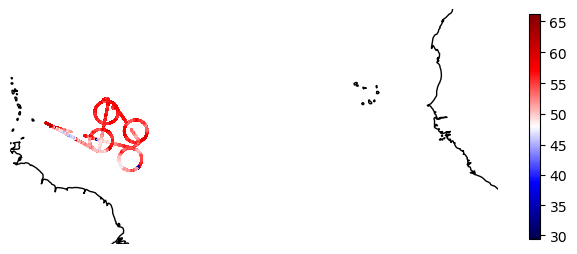

<xarray.DataArray 'time' ()> Size: 8B
array('2024-09-14T11:07:11.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-09-14T11:07:11


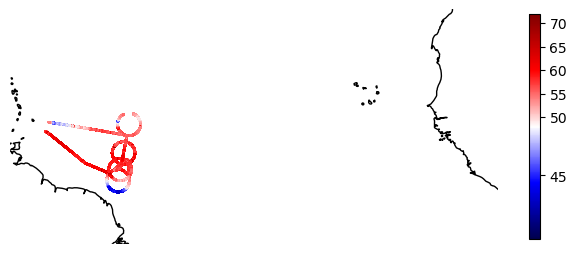

<xarray.DataArray 'time' ()> Size: 8B
array('2024-09-16T09:46:49.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-09-16T09:46:49


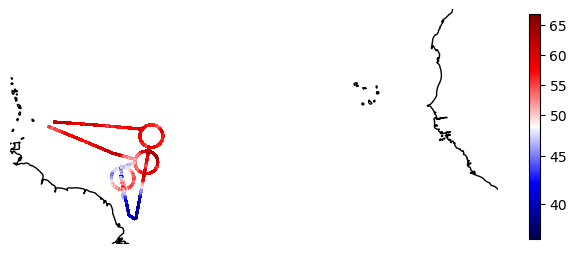

<xarray.DataArray 'time' ()> Size: 8B
array('2024-09-19T08:52:53.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-09-19T08:52:53


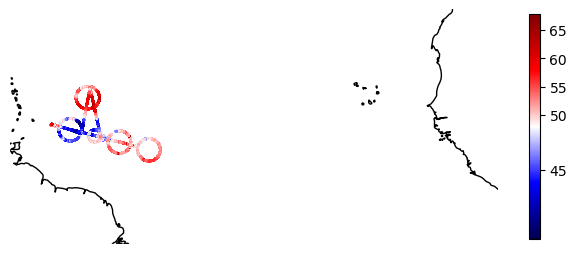

<xarray.DataArray 'time' ()> Size: 8B
array('2024-09-21T10:48:30.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-09-21T10:48:30


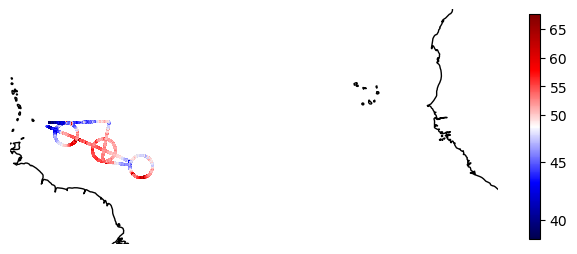

<xarray.DataArray 'time' ()> Size: 8B
array('2024-09-23T09:20:44.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-09-23T09:20:44


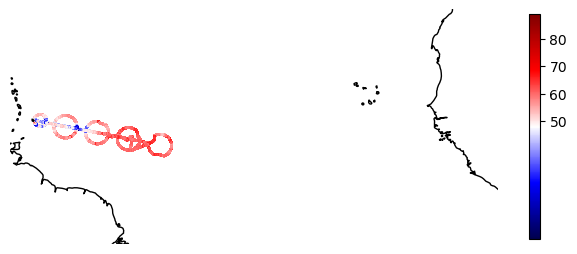

<xarray.DataArray 'time' ()> Size: 8B
array('2024-09-24T15:48:45.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-09-24T15:48:45


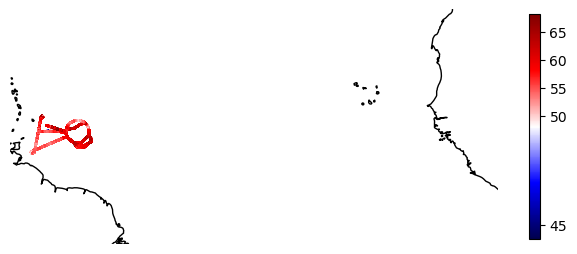

<xarray.DataArray 'time' ()> Size: 8B
array('2024-09-26T11:14:48.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-09-26T11:14:48


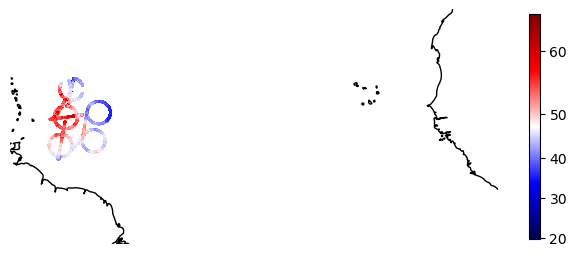

<xarray.DataArray 'time' ()> Size: 8B
array('2024-09-28T08:56:14.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-09-28T08:56:14


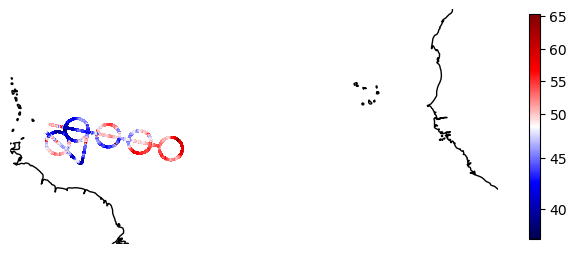

<xarray.DataArray 'time' ()> Size: 8B
array('2024-09-29T21:43:28.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-09-29T21:43:28


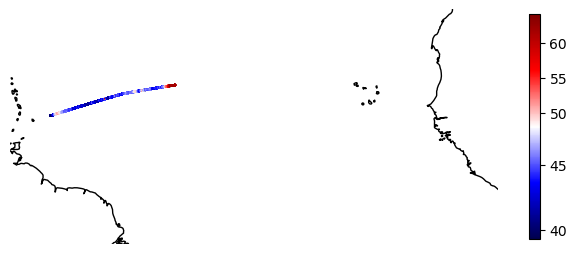

<xarray.DataArray 'time' ()> Size: 8B
array('2024-09-30T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-09-30


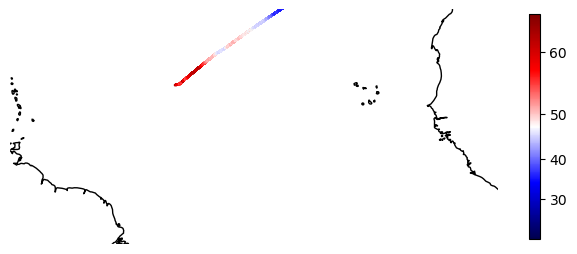

<xarray.DataArray 'time' ()> Size: 8B
array('2024-08-09T05:03:25.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-08-09T05:03:25


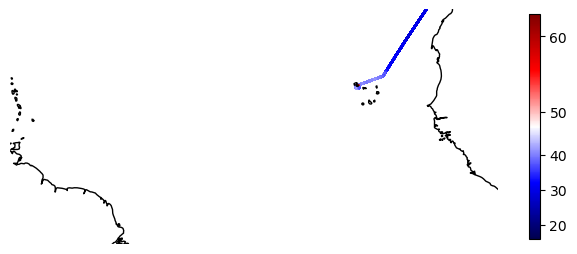

<xarray.DataArray 'time' ()> Size: 8B
array('2024-08-11T11:00:43.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-08-11T11:00:43


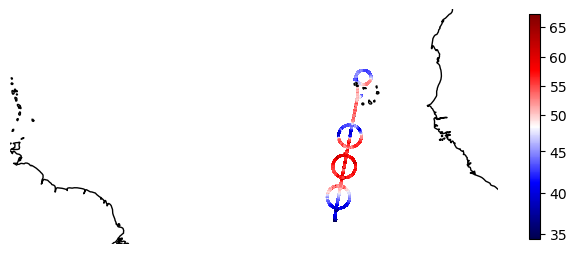

<xarray.DataArray 'time' ()> Size: 8B
array('2024-08-13T11:38:42.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-08-13T11:38:42


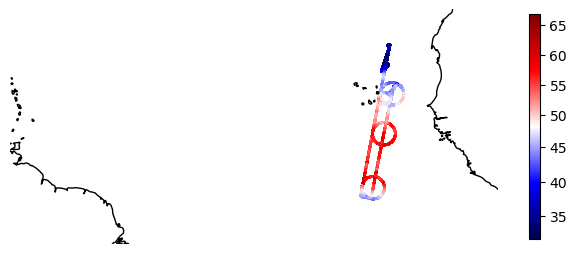

<xarray.DataArray 'time' ()> Size: 8B
array('2024-08-16T08:02:26.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-08-16T08:02:26


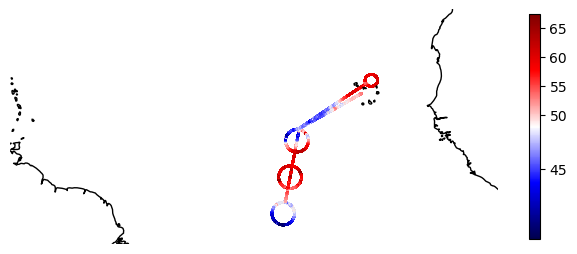

<xarray.DataArray 'time' ()> Size: 8B
array('2024-08-18T07:26:59.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-08-18T07:26:59


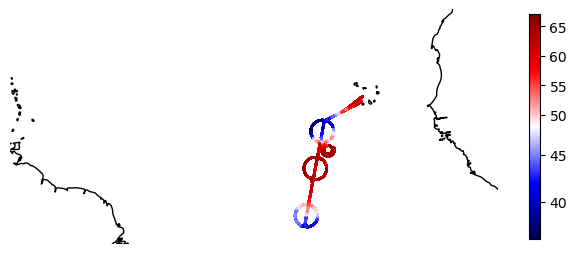

<xarray.DataArray 'time' ()> Size: 8B
array('2024-08-21T09:51:55.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-08-21T09:51:55


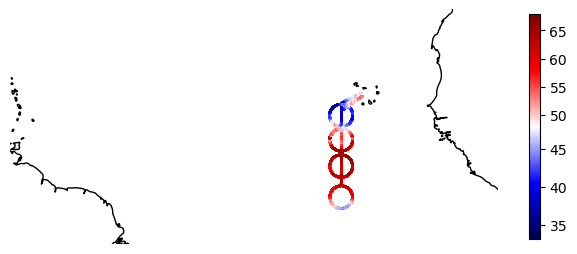

<xarray.DataArray 'time' ()> Size: 8B
array('2024-08-22T08:33:52.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-08-22T08:33:52


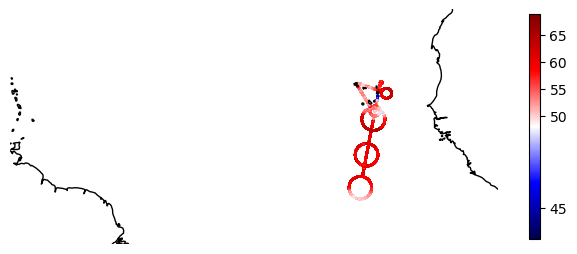

<xarray.DataArray 'time' ()> Size: 8B
array('2024-08-25T07:00:37.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-08-25T07:00:37


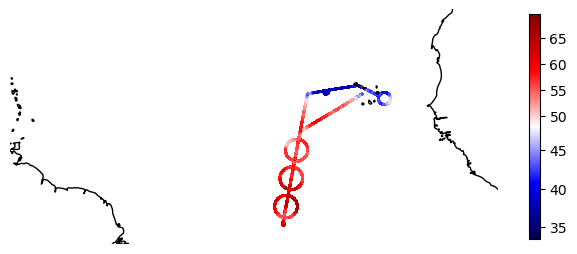

<xarray.DataArray 'time' ()> Size: 8B
array('2024-08-27T07:15:56.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-08-27T07:15:56


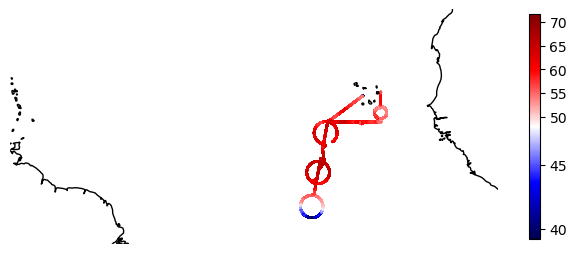

<xarray.DataArray 'time' ()> Size: 8B
array('2024-08-29T09:32:37.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-08-29T09:32:37


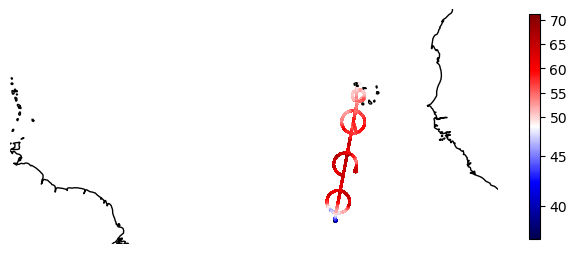

<xarray.DataArray 'time' ()> Size: 8B
array('2024-08-31T06:21:10.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-08-31T06:21:10


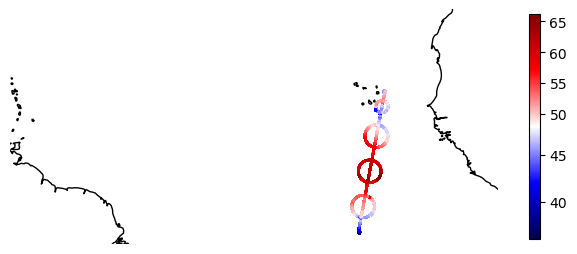

<xarray.DataArray 'time' ()> Size: 8B
array('2024-09-03T07:57:49.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-09-03T07:57:49


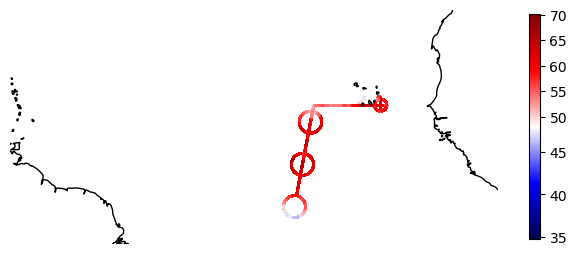

<xarray.DataArray 'time' ()> Size: 8B
array('2024-09-06T10:21:43.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-09-06T10:21:43


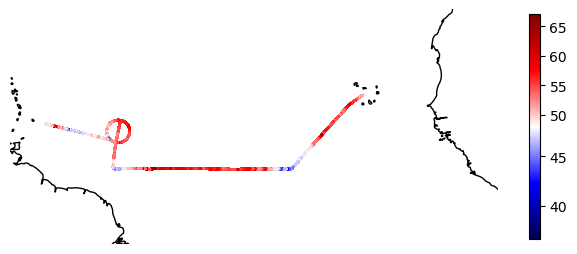

<xarray.DataArray 'time' ()> Size: 8B
array('2024-09-07T11:22:27.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-09-07T11:22:27


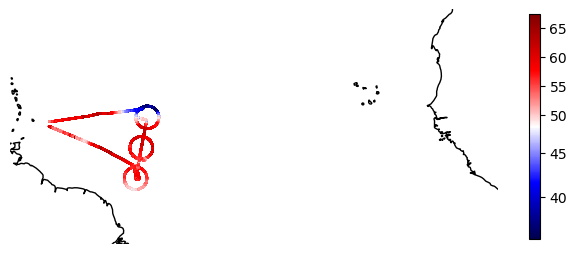

<xarray.DataArray 'time' ()> Size: 8B
array('2024-09-09T10:06:14.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2024-09-09T10:06:14


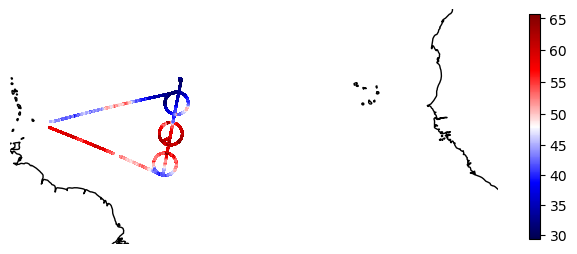

In [24]:
#
flights=list(set(ds_hamp['time.dayofyear'].values))
for flight in flights:
    ds_hamp_f=ds_hamp.sel(time=(ds_hamp.time.dt.dayofyear == flight))
    print(ds_hamp_f.isel(time=0).time)
    plot_flights_IWV(ds_hamp_f)
    

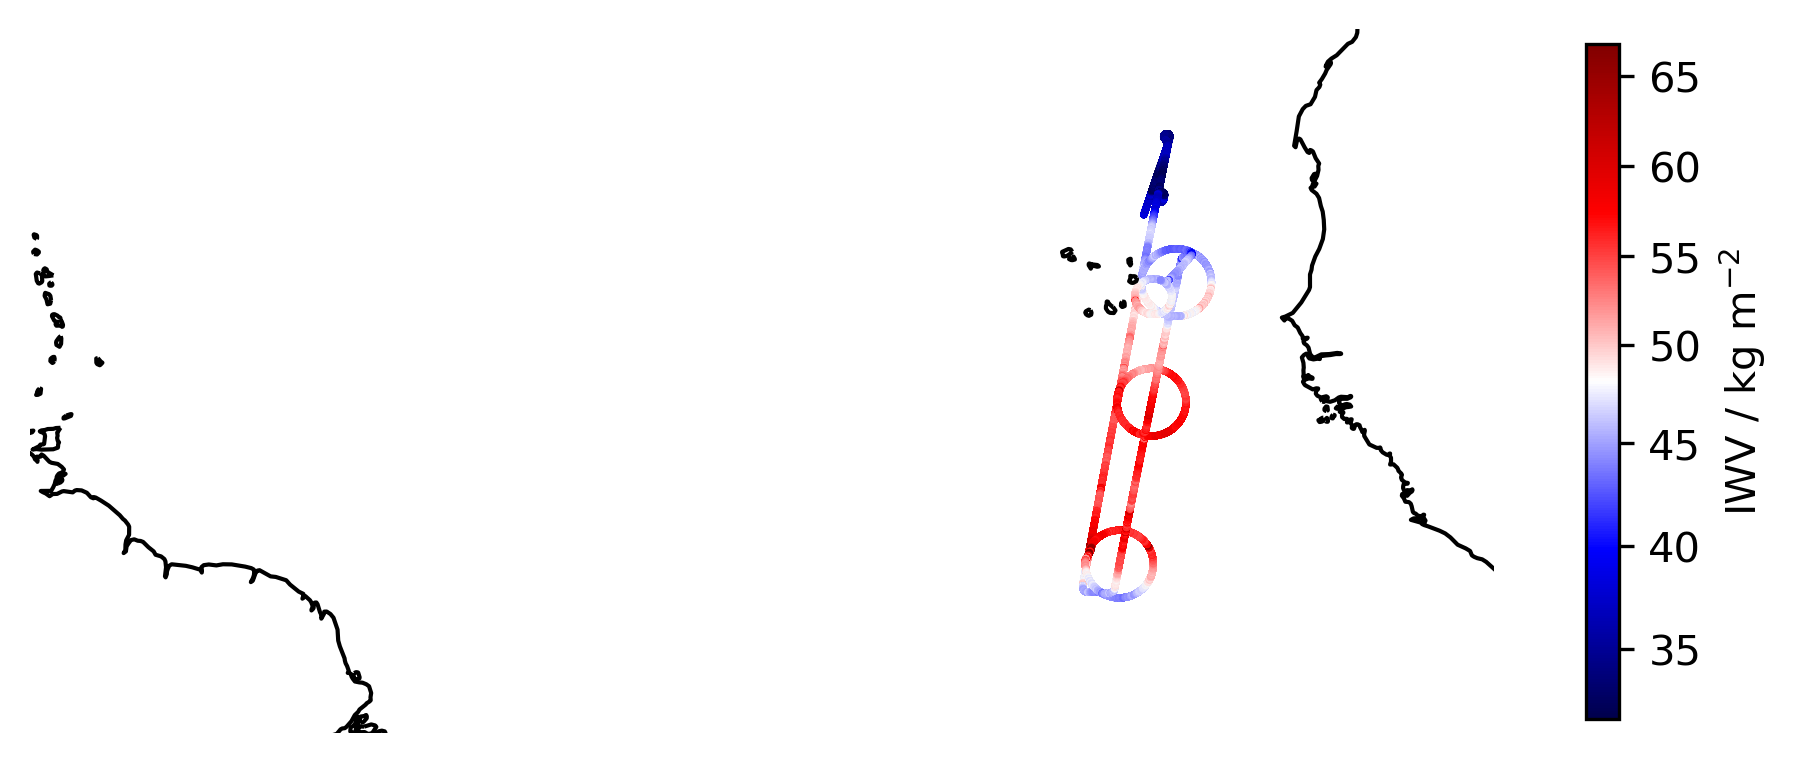

In [35]:
target_day='2024-09-09'
ds_hamp_f=ds_hamp.sel(time=target_day)
#plot_flights_IWV(ds_hamp_f)

target_day='2024-08-13'
ds_hamp_f=ds_hamp.sel(time=target_day)
plot_flights_IWV(ds_hamp_f,filename=target_day)

In [34]:
target_day='2024-09-09'

ds_hamp_f=ds_hamp.sel(time=target_day)

def plot_flights_IWV(ds_hamp_f,filename=None):    
    plt.rcParams['figure.dpi'] = 300
    plt.rcParams['savefig.dpi'] = 400
    lon = ds_hamp_f.lon.values  # Longitudes
    lat = ds_hamp_f.lat.values  # Latitudes
    iwv_values = ds_hamp_f.IWV.values  # IWV values #oder IWV_rolling
    cmap = plt.get_cmap('seismic')  # Choose a colormap
    #norm = plt.Normalize(np.min([np.nanmin(iwv_values),np.nanmin(ds_sondes_f.iwv)]),np.max([np.nanmax(iwv_values),np.nanmax(ds_sondes_f.iwv)] ))
    divnorm = colors.TwoSlopeNorm(vmin=np.nanmin(iwv_values), vcenter=48, vmax=np.nanmax(iwv_values))
    #cmap= colors.LinearSegmentedColormap.from_list(    'bone', 'cool')
    
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE)
    #ax.gridlines(draw_labels=True)
    ax.set_axis_off()
    sc = ax.scatter(lon, lat, c=iwv_values, s=0.5, cmap=cmap, norm=divnorm, transform=ccrs.PlateCarree())
    cbar = plt.colorbar(sc, ax=ax, orientation='vertical',shrink=0.5)
    cbar.set_label('IWV / kg m$^{-2}$')
    plt.xlim((-62,-10))
    
    plt.ylim((0,25))
    plt.tight_layout()
    if filename:    
        plt.savefig(f'/home/u/u301032/orcestra/plots/flight_map_IWV_{filename}.png')

    plt.show()

#### plot all flights

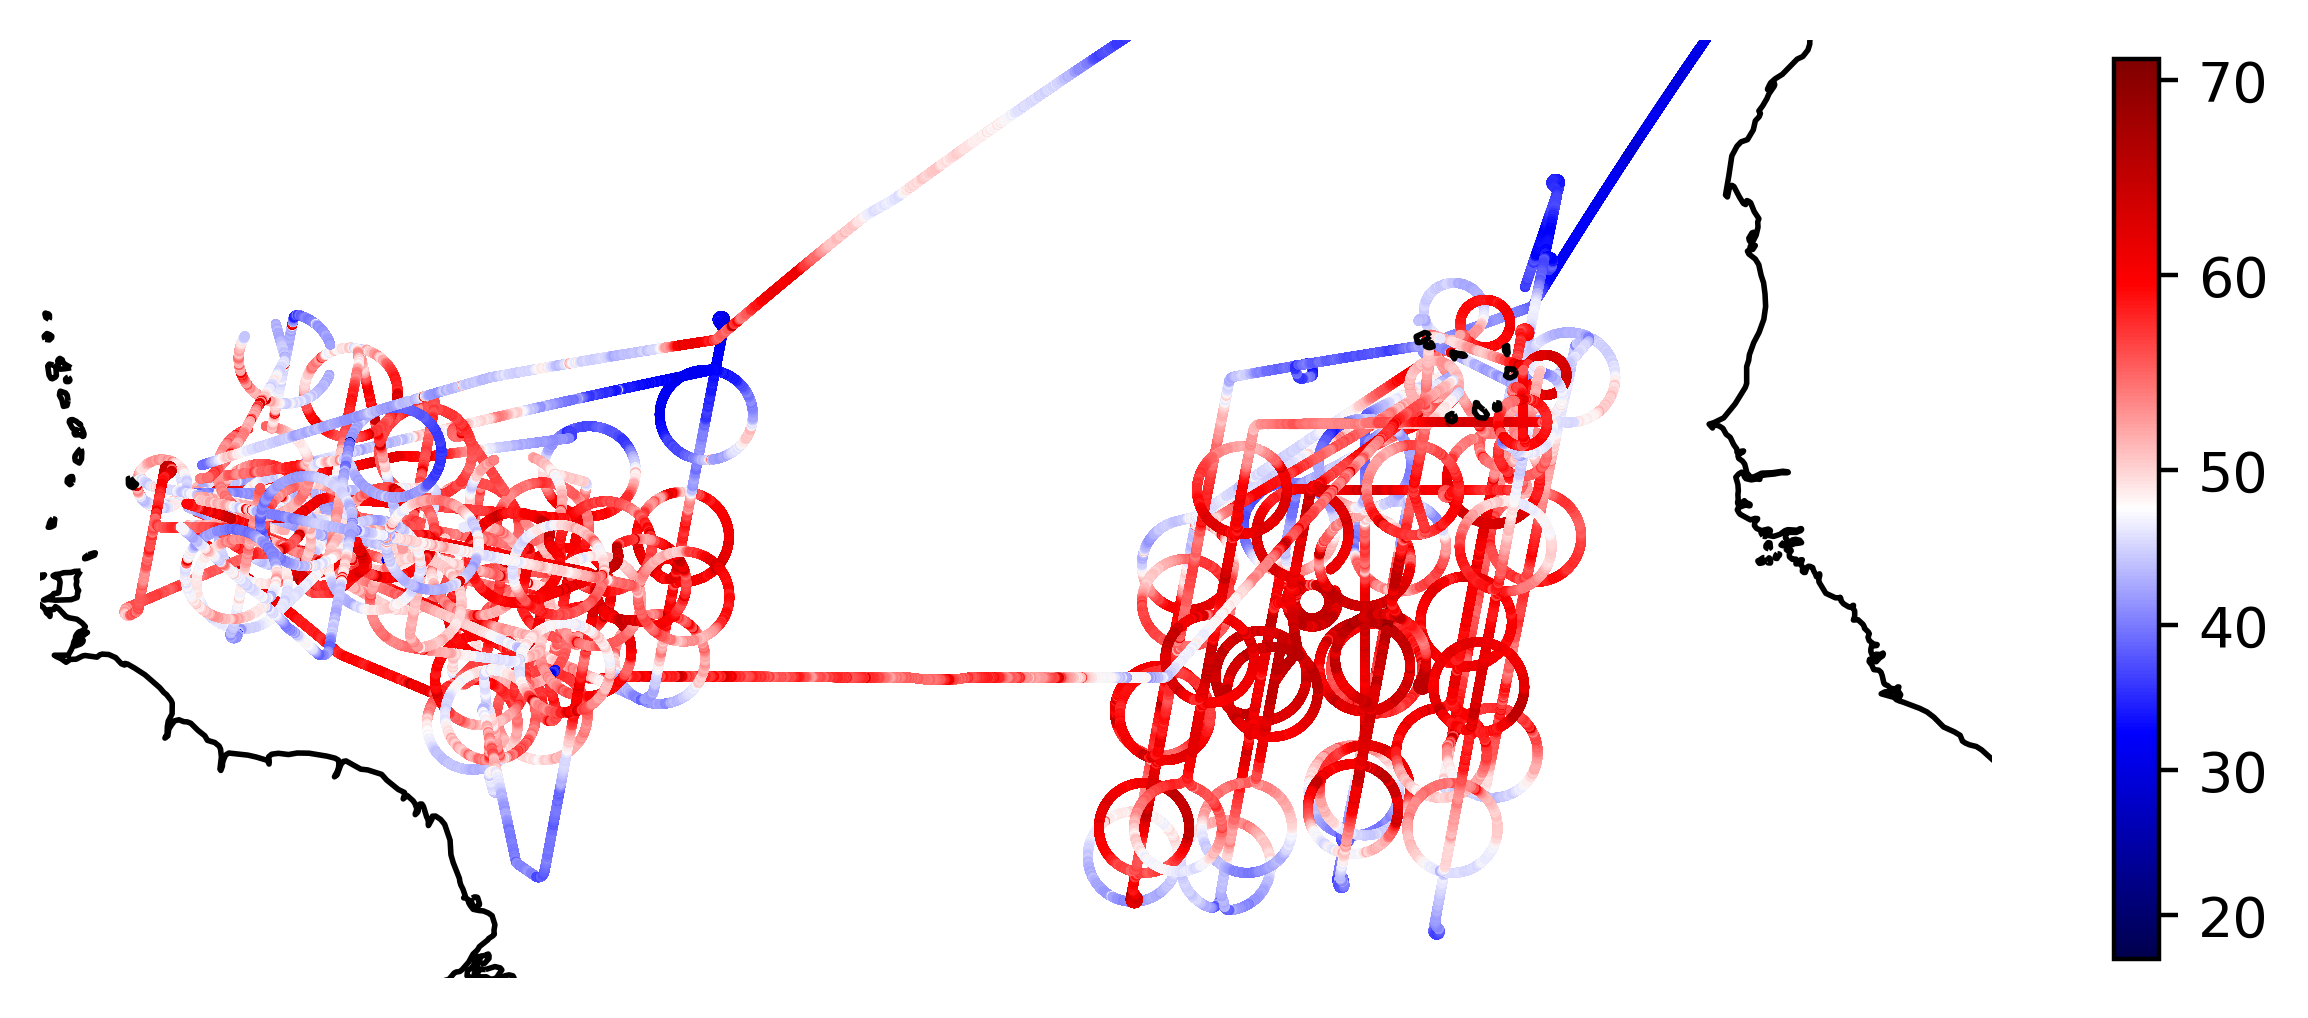

In [22]:
# Get the values and locations for plotting
plt.rcParams['figure.dpi'] = 400
lon = ds_hamp.lon.values  # Longitudes
lat = ds_hamp.lat.values  # Latitudes
iwv_values = ds_hamp.IWV.values  # IWV values #oder IWV_rolling
cmap = plt.get_cmap('seismic')  # Choose a colormap
#norm = plt.Normalize(np.min([np.nanmin(iwv_values),np.nanmin(ds_sondes_f.iwv)]),np.max([np.nanmax(iwv_values),np.nanmax(ds_sondes_f.iwv)] ))
divnorm = colors.TwoSlopeNorm(vmin=np.nanmin(iwv_values), vcenter=48, vmax=np.nanmax(iwv_values))
#cmap= colors.LinearSegmentedColormap.from_list(    'bone', 'cool')

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
#ax.gridlines(draw_labels=True)
ax.set_axis_off()
sc = ax.scatter(lon, lat, c=iwv_values, s=0.5, cmap=cmap, norm=divnorm, transform=ccrs.PlateCarree())
cbar = plt.colorbar(sc, ax=ax, orientation='vertical',shrink=0.5)
#cbar.set_label('IWV \\ kg m$^{-2}$')
plt.xlim((-62,-10))

plt.ylim((0,25))
plt.tight_layout()

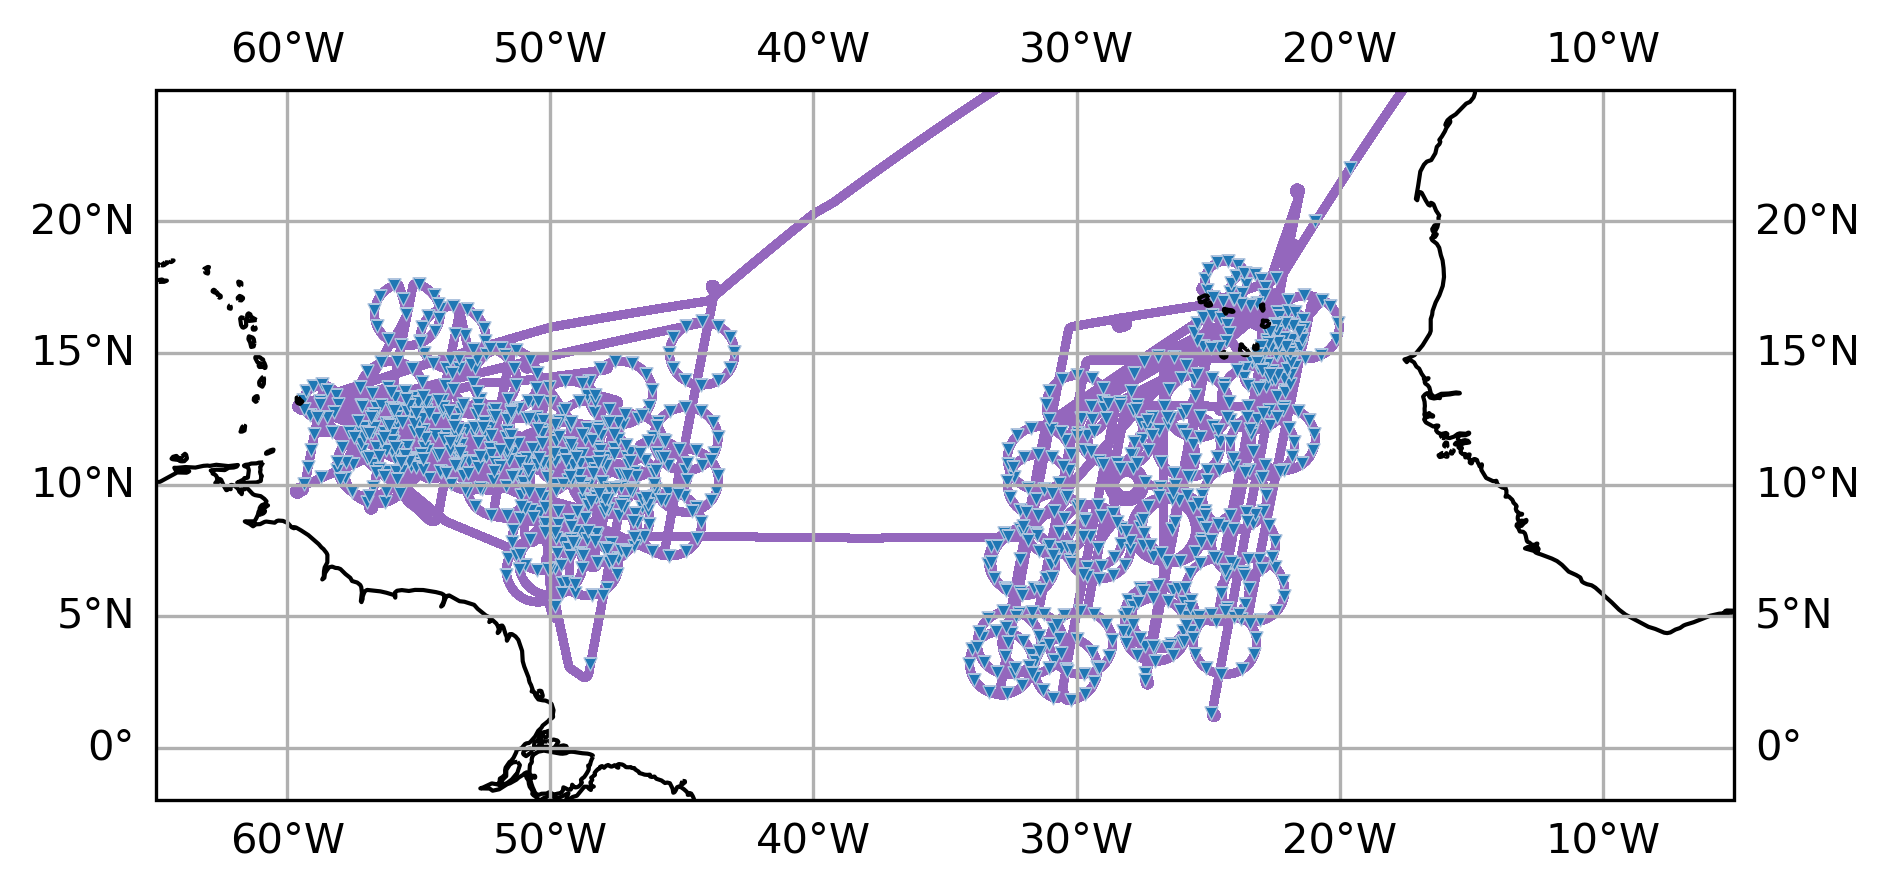

In [11]:
# Get the values and locations for plotting
plt.rcParams['figure.dpi'] = 300
lon = ds_hamp.lon.values  # Longitudes
lat = ds_hamp.lat.values  # Latitudes

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)

ax.gridlines(draw_labels=True)
#ax.set_axis_off()

sc = ax.scatter(lon, lat,  s=0.7, transform=ccrs.PlateCarree(), color='tab:purple')
sc_sondes = ax.scatter(ds_sondes.aircraft_longitude, ds_sondes.aircraft_latitude,marker='v',color='C0',linewidth=0.3, edgecolor='lightsteelblue',s=10,transform=ccrs.PlateCarree())#, edgecolor='black'# edgecolor='lightsteelblue', linewidth=0.3, 

plt.xlim((-65,-5))

plt.ylim((-2,25))
plt.tight_layout()
plt.savefig(f'/home/u/u301032/orcestra/plots/map_halo_sondes.png')

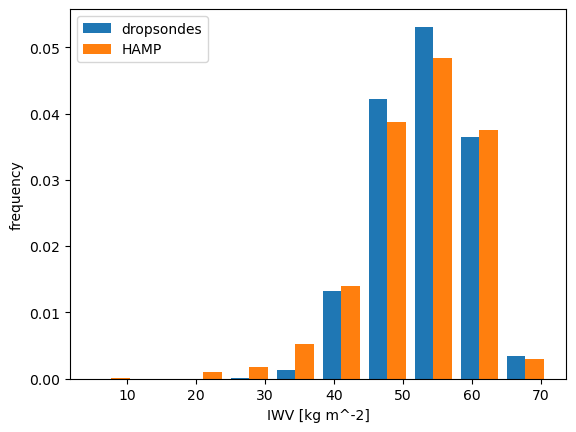

NameError: name 'sel_target_date' is not defined

In [2]:
#%% PLOT 3D DATAof retrieval
#open datasets including new iwv
ds_hamp=xr.open_dataset('/work/um0203/u301032/master_thesis/retrieved_data/HAMP_with_IWV_IWP_LWP_v1-1.nc')
#ds_iwv_kw=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_iwv_kw.nc")
ds_sondes=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_sondes.nc")
ds_halo_altitude=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_altitude.nc") 
#%% histograms sondes vs halo
plt.hist([ds_sondes.iwv,ds_hamp.IWV],label=['dropsondes','HAMP'],density=True)


plt.legend()
plt.xlabel("IWV [kg m^-2]")
plt.ylabel("frequency")
plt.show()

#%%
#selecting target day
target_day='2024-09-07'
target_date=target_day
ds_sondes_f=sel_target_date(target_date,ds_sondes)
print(ds_sondes_f.sonde_time)
ds_hamp_f=sel_target_date(target_date,ds_hamp)
print(ds_hamp_f.time)
ds_halo_altitude_f=sel_target_date(target_date,ds_halo_altitude)
print(ds_halo_altitude_f.time)

df = ds_hamp_f['IWV'].to_dataframe().reset_index()


df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time')

# Set time as the index for rolling calculation
df.set_index('time', inplace=True)

# Calculate the rolling mean with a 10-second window
df['IWV_rolling'] = df['IWV'].rolling('10s').mean()

# Reset index to revert back to a regular DataFrame
df.reset_index(inplace=True)

# Convert back to xarray DataArray
rolling_iwv = xr.DataArray(df['IWV_rolling'].values, 
                            coords=[df['time'].values], 
                            dims=['time'])

ds_hamp_f['IWV_rolling'] = rolling_iwv
#%% PLOT PLOT PLOT
# if all, instead of target day
ds_sondes_f = ds_sondes
ds_hamp_f = ds_hamp

import matplotlib.colors as colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)

# Get the values and locations for plotting
lon = ds_hamp_f.lon.values  # Longitudes
lat = ds_hamp_f.lat.values  # Latitudes
iwv_values = ds_hamp_f.IWV.values  # IWV values #oder IWV_rolling

# Normalize the IWV values for colormap
norm = plt.Normalize(np.min([np.nanmin(iwv_values),np.nanmin(ds_sondes_f.iwv)]),np.max([np.nanmax(iwv_values),np.nanmax(ds_sondes_f.iwv)] ))
#norm = divnorm = colors.TwoSlopeNorm(vmin=np.nanmin(iwv_values), vcenter=50, vmax=np.nanmax(iwv_values))
#cmap= colors.LinearSegmentedColormap.from_list(    'bone', 'cool')
colors.LogNorm(np.min([np.nanmin(iwv_values),np.nanmin(ds_sondes_f.iwv)]),np.max([np.nanmax(iwv_values),np.nanmax(ds_sondes_f.iwv)] ))

cmap = plt.get_cmap('winter')  # Choose a colormap

sc = ax.scatter(lon, lat, c=iwv_values, s=0.5, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())

#sc2 = ax.scatter(lon, lat, c=iwv_values2, s=0.5, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())

"""
# Create your scatter plot with filled triangles
sc_sondes_fill = ax.scatter(ds_sondes_f.aircraft_longitude, ds_sondes_f.aircraft_latitude,
                             norm=norm, c=ds_sondes_f.iwv, s=30, cmap=cmap, 
                             transform=ccrs.PlateCarree(), marker='^')  # Use triangle marker

# Overlay the scatter plot with black outlines
sc_sondes_outline = ax.scatter(ds_sondes_f.aircraft_longitude, ds_sondes_f.aircraft_latitude,
                                c='none', edgecolor='black', s=30, 
                                marker='^', transform=ccrs.PlateCarree())
"""
# Create a scatter plot with varying colors
#sc_sondes = ax.scatter(ds_sondes_f.aircraft_longitude, ds_sondes_f.aircraft_latitude,norm=norm, edgecolor='black', c=ds_sondes_f.iwv, s=10, cmap=cmap, transform=ccrs.PlateCarree())



# Add a colorbar
cbar = plt.colorbar(sc, ax=ax, orientation='vertical',norm=norm,shrink=0.7)
cbar.set_label('IWV [kg m-2]')
#plt.xlim((-62,-40))

#plt.ylim((3,18))

plt.xlim((-62,-10))

plt.ylim((0,25))

#plt.title("Flight day "+target_day)
plt.rcParams['figure.dpi'] = 400
plt.rcParams['savefig.dpi'] = 400
plt.show()
#plt.savefig('/home/u/u301032/orcestra/plots/plot-iwv'+target_day+'.jpg', dpi=300)
